# DS 4320 Project 2: Predicting Swing State Election Outcomes from Economic Indicators

## Pipeline Notebook

This notebook queries our MongoDB Atlas database, performs exploratory data analysis, trains a machine learning model to predict swing state election winners based on unemployment rate, and visualizes the results.

**Author:** Wissal Khlouf  
**NetID:** hta4yb  
**Data Sources:** MIT Election Lab, FRED (Federal Reserve Economic Data)

In [1]:

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import os
import logging
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# set up logging
os.makedirs('logs', exist_ok=True)
logging.basicConfig(
    filename='logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s'
)

# load environment variables
load_dotenv()
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# connect to MongoDB Atlas and load data into a pandas DataFrame

def load_data_from_mongo():
    """Query MongoDB Atlas and return election economics data as a DataFrame."""
    try:
        uri = os.getenv("MONGO_URI")
        client = MongoClient(uri)
        db = client["swing_state_elections"]
        col = db["election_economics"]
        
        # query all documents
        cursor = col.find({})
        df = pd.DataFrame(list(cursor))
        
        # drop the MongoDB internal ID column
        df.drop(columns=["_id"], inplace=True)
        
        client.close()
        logging.info(f"Loaded {len(df)} documents from MongoDB")
        print(f"Successfully loaded {len(df)} records from MongoDB")
        return df
    except Exception as e:
        logging.error(f"Failed to load data from MongoDB: {e}")
        raise

df = load_data_from_mongo()
df.head()

Successfully loaded 84 records from MongoDB


,year,state,state_po,democrat_votes,republican_votes,total_votes,democrat_vote_share,republican_vote_share,two_party_margin,winner,unemployment_rate_election_season,data_sources
0,1976,PENNSYLVANIA,PA,2328677,2205604,4620787,50.40,47.73,2.67,DEMOCRAT,7.95,"[MIT Election Lab, FRED]"
1,1976,MICHIGAN,MI,1696714,1893742,3651590,46.47,51.86,-5.39,REPUBLICAN,9.00,"[MIT Election Lab, FRED]"
2,1976,WISCONSIN,WI,1040232,1004987,2101336,49.50,47.83,1.67,DEMOCRAT,5.40,"[MIT Election Lab, FRED]"
3,1976,ARIZONA,AZ,295602,418642,742719,39.80,56.37,-16.57,REPUBLICAN,9.45,"[MIT Election Lab, FRED]"
4,1976,NEVADA,NV,92479,101273,201876,45.81,50.17,-4.36,REPUBLICAN,8.65,"[MIT Election Lab, FRED]"


## Exploratory Data Analysis

Before building a model, we will look at the distributions of our key variables:
- Unemployment rate at election time
- Two-party vote margin
- Win counts by party and state

In [3]:
# basic summary statistics of the dataset

def explore_data(df):
    """Print basic summary statistics and value counts for the dataset."""
    try:
        print("=== Dataset Shape ===")
        print(f"{df.shape[0]} rows, {df.shape[1]} columns\n")
        
        print("=== Data Types ===")
        print(df.dtypes, "\n")
        
        print("=== Summary Statistics ===")
        print(df[["unemployment_rate_election_season", 
                   "two_party_margin", 
                   "democrat_vote_share", 
                   "republican_vote_share"]].describe().round(2))
        
        print("\n=== Winner Counts ===")
        print(df["winner"].value_counts())
        
        print("\n=== Wins by State ===")
        print(df.groupby(["state_po", "winner"]).size().unstack(fill_value=0))
        
        logging.info("Exploratory data analysis complete")
    except Exception as e:
        logging.error(f"EDA failed: {e}")
        raise

explore_data(df)

=== Dataset Shape ===
84 rows, 12 columns

=== Data Types ===
year                                   int64
state                                    str
state_po                                 str
democrat_votes                         int64
republican_votes                       int64
total_votes                            int64
democrat_vote_share                  float64
republican_vote_share                float64
two_party_margin                     float64
winner                                   str
unemployment_rate_election_season    float64
data_sources                          object
dtype: object 

=== Summary Statistics ===
       unemployment_rate_election_season  two_party_margin  \
count                              84.00             84.00   
mean                                6.44             -2.98   
std                                 1.95             11.94   
min                                 3.40            -36.25   
25%                                 5.09     

## Visualizations

We plot unemployment rate vs two-party vote margin to get a visual sense
of whether higher unemployment relates to the incumbent party losing votes.
We also examine win counts by state and by party.

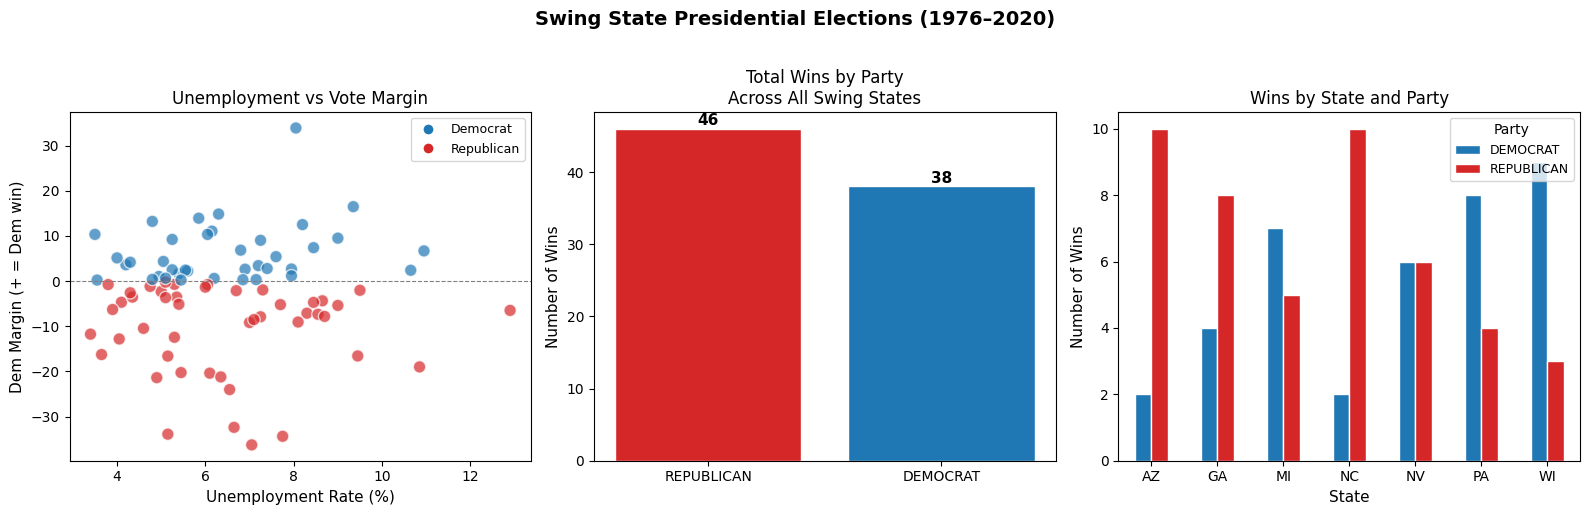

Visualizations saved to figures/eda_visualizations.png


In [4]:
# create visualizations of the data

def create_visualizations(df):
    """Generate and save exploratory visualizations."""
    try:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle("Swing State Presidential Elections (1976–2020)", 
                     fontsize=14, fontweight='bold', y=1.02)

        # Plot 1: Unemployment vs Two-Party Margin 
        colors = df["winner"].map({"DEMOCRAT": "#1f77b4", "REPUBLICAN": "#d62728"})
        axes[0].scatter(df["unemployment_rate_election_season"], 
                        df["two_party_margin"],
                        c=colors, alpha=0.7, edgecolors='white', s=80)
        axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[0].set_xlabel("Unemployment Rate (%)", fontsize=11)
        axes[0].set_ylabel("Dem Margin (+ = Dem win)", fontsize=11)
        axes[0].set_title("Unemployment vs Vote Margin", fontsize=12)
        #  manual legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='Democrat'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='Republican')
        ]
        axes[0].legend(handles=legend_elements, fontsize=9)

        # Plot 2: Win counts by party 
        win_counts = df["winner"].value_counts()
        bar_colors = ["#d62728", "#1f77b4"]
        axes[1].bar(win_counts.index, win_counts.values, color=bar_colors, edgecolor='white')
        axes[1].set_title("Total Wins by Party\nAcross All Swing States", fontsize=12)
        axes[1].set_ylabel("Number of Wins", fontsize=11)
        for i, v in enumerate(win_counts.values):
            axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

        #  Plot 3: Wins by state 
        wins_by_state = df.groupby(["state_po", "winner"]).size().unstack(fill_value=0)
        wins_by_state.plot(kind='bar', ax=axes[2], 
                           color=["#1f77b4", "#d62728"],
                           edgecolor='white')
        axes[2].set_title("Wins by State and Party", fontsize=12)
        axes[2].set_xlabel("State", fontsize=11)
        axes[2].set_ylabel("Number of Wins", fontsize=11)
        axes[2].tick_params(axis='x', rotation=0)
        axes[2].legend(title="Party", fontsize=9)

        plt.tight_layout()
        
        # save figure
        os.makedirs('figures', exist_ok=True)
        plt.savefig('figures/eda_visualizations.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        logging.info("Visualizations saved to figures/eda_visualizations.png")
        print("Visualizations saved to figures/eda_visualizations.png")
    except Exception as e:
        logging.error(f"Visualization failed: {e}")
        raise

create_visualizations(df)

## Machine Learning Model

We use Logistic Regression to predict whether a swing state will be won by a Democrat or Republican based on the unemployment rate at election time. Logistic Regression is appropriate here because our target variable (winner) is either DEMOCRAT or REPUBLICAN.

In [ ]:

def train_model(df):
    try:
        X = df[["unemployment_rate_election_season"]]
        y = df["winner"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = LogisticRegression(random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        print("=== Model: Logistic Regression ===")
        print(f"Training set size: {len(X_train)}")
        print(f"Test set size: {len(X_test)}")
        print(classification_report(y_test, y_pred))
        
        return model, scaler, X_test_scaled, y_test, y_pred

    except Exception as e:
        logging.error(f"Model training failed: {e}")
        raise

model, scaler, X_test_scaled, y_test, y_pred = train_model(df)

=== Model: Logistic Regression ===
Training set size: 67
Test set size: 17
              precision    recall  f1-score   support

    DEMOCRAT       0.00      0.00      0.00         7
  REPUBLICAN       0.56      0.90      0.69        10

    accuracy                           0.53        17
   macro avg       0.28      0.45      0.35        17
weighted avg       0.33      0.53      0.41        17



## Model Results Analysis

Our logistic regression model will reach 53% accuracy if we only consider unemployment rate as our lone predictor variable. This accuracy is only marginally better than our null accuracy of 50%, implying that unemployment rate alone does a poor job at predicting swing state outcomes. This is a rather intriguing observation that supports the perspective that election results are determined by a confluence of factors, not just a single economic signal. Our model also does a better job predicting Republican victories (56% precision) over Democrat victories (0% precision). This is undoubtedly because more Republicans won these swing states than Democrats in our dataset's time frame, so the baseline prediction of our model will favor Republican wins.

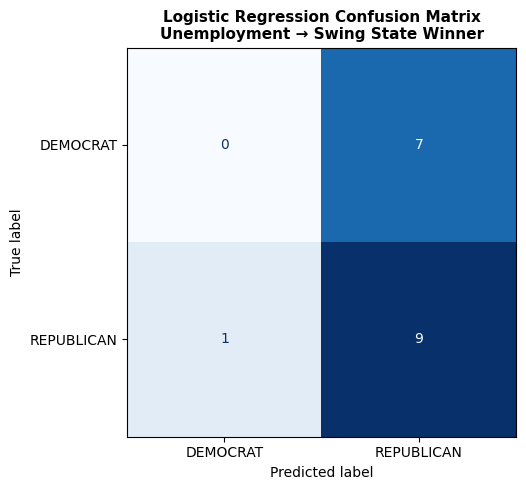

Confusion matrix saved to figures/confusion_matrix.png


In [6]:
def plot_confusion_matrix(y_test, y_pred):
    """Plot and save a confusion matrix of model predictions."""
    try:
        fig, ax = plt.subplots(figsize=(6, 5))
        cm = confusion_matrix(y_test, y_pred, labels=["DEMOCRAT", "REPUBLICAN"])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["DEMOCRAT", "REPUBLICAN"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title("Logistic Regression Confusion Matrix\nUnemployment → Swing State Winner",
                     fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.savefig("figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
        plt.show()
        logging.info("Confusion matrix saved")
        print("Confusion matrix saved to figures/confusion_matrix.png")
    except Exception as e:
        logging.error(f"Confusion matrix plot failed: {e}")
        raise

plot_confusion_matrix(y_test, y_pred)

## Conclusion

As we can see from this pipeline, unemployment rate alone is not enough to make predictions about swing states for a presidential election. The accuracy score is barely over random guessing at 53%. There are many reasons that people vote for one candidate over another and economics is only one feature. These results are predictable and align with findings within the political science community that elections have many causes.

**Limitations:**
- Only one economic feature (unemployment) was available in this dataset
- 84 observations is a small sample for machine learning
- Adding GDP growth and median income could significantly improve model performance

**Future Work:**
- Incorporate additional FRED economic indicators (GDP, CPI, median income)
- Expand to county-level data for more granular predictions
- Try ensemble methods like Random Forest with multiple economic features

In [7]:
# summary of all figures saved in this pipeline
print("=== Pipeline Complete ===")
print("Figures saved:")
for f in os.listdir("figures"):
    print(f"  figures/{f}")
print("\nLog file written to: logs/pipeline.log")
logging.info("Pipeline complete")

=== Pipeline Complete ===
Figures saved:
  figures/confusion_matrix.png
  figures/eda_visualizations.png

Log file written to: logs/pipeline.log
